In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler 

In [6]:
# Load dataset
df_ins = pd.read_csv('insurance_claims.csv')

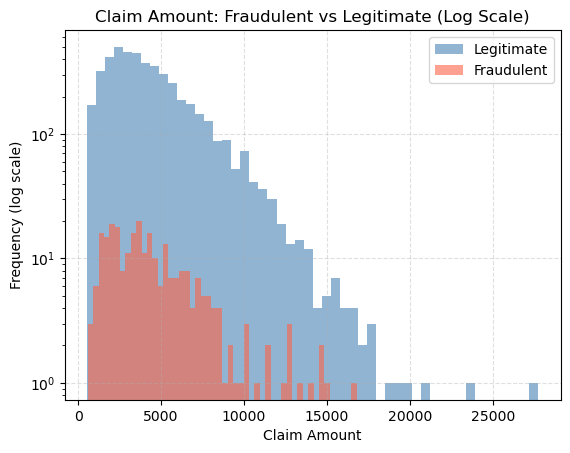

In [14]:
# 1. Histograms of claim_amount for fraudulent vs legitimate (log scale)
fraud = df_ins[df_ins['fraud_flag'] == 1]['claim_amount']
legit = df_ins[df_ins['fraud_flag'] == 0]['claim_amount']
 
plt.hist(legit, bins=50, alpha=0.6, color='steelblue', label='Legitimate', log=True)
plt.hist(fraud, bins=50, alpha=0.6, color='tomato',    label='Fraudulent', log=True)
plt.xlabel('Claim Amount')
plt.ylabel('Frequency (log scale)')
plt.title('Claim Amount: Fraudulent vs Legitimate (Log Scale)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

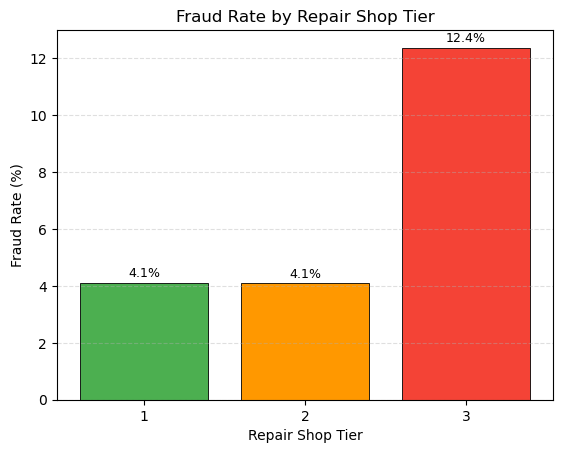

In [15]:
# 2. Bar chart showing fraud rate by repair shop tier
fraud_by_tier = df_ins.groupby('repair_shop_tier')['fraud_flag'].mean() * 100
plt.bar(fraud_by_tier.index, fraud_by_tier.values,
               color=['#4CAF50', '#FF9800', '#F44336'], edgecolor='black', linewidth=0.6)
plt.xlabel('Repair Shop Tier')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Repair Shop Tier')
plt.xticks([1, 2, 3])
for i, v in enumerate(fraud_by_tier.values):
    plt.text(fraud_by_tier.index[i], v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.4, axis='y')
 

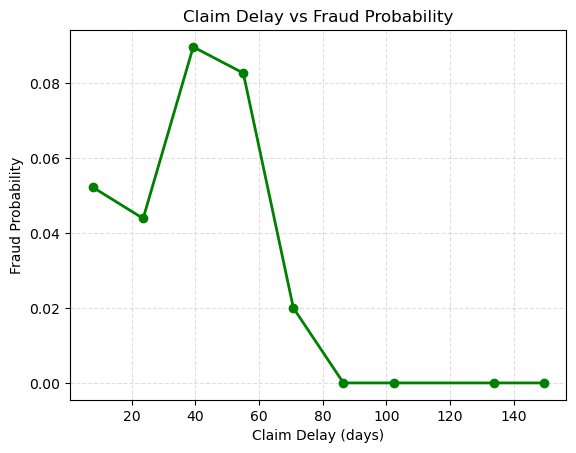

In [18]:
# 3. Claim delay vs fraud probability
df_ins['delay_bin'] = pd.cut(df_ins['claim_delay_days'], bins=10)
delay_fraud = df_ins.groupby('delay_bin', observed=True)['fraud_flag'].mean()
bin_midpoints = [interval.mid for interval in delay_fraud.index]
plt.plot(bin_midpoints, delay_fraud.values, marker='o', color='green', linewidth=2)
plt.xlabel('Claim Delay (days)')
plt.ylabel('Fraud Probability')
plt.title('Claim Delay vs Fraud Probability')
plt.grid(True, linestyle='--', alpha=0.4)
 

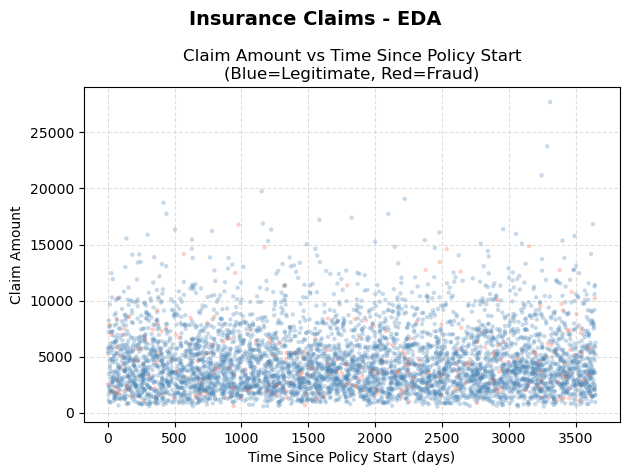

In [20]:
# 4. Scatter: claim_amount vs time_since_policy_start_days, colored by fraud status
colors = df_ins['fraud_flag'].map({0: 'steelblue', 1: 'tomato'})
plt.scatter(df_ins['time_since_policy_start_days'], df_ins['claim_amount'],
                   c=colors, alpha=0.3, s=10, edgecolors='none')
plt.xlabel('Time Since Policy Start (days)')
plt.ylabel('Claim Amount')
plt.title('Claim Amount vs Time Since Policy Start\n(Blue=Legitimate, Red=Fraud)')
plt.grid(True, linestyle='--', alpha=0.4)
 
plt.suptitle('Insurance Claims - EDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show(block=False)

In [24]:
# ----------------------------------------------------------
# Activity 2: Logistic Regression with Interaction Terms (10 marks)
# ----------------------------------------------------------
 
# 1. Create interaction features
df_ins['amount_delay']   = df_ins['claim_amount'] * df_ins['claim_delay_days']
df_ins['high_value_new'] = (df_ins['time_since_policy_start_days'] < 90).astype(int) * \
                            (df_ins['claim_amount'] > 10000).astype(int)
 
# Drop helper column
df_ins.drop(columns=['delay_bin'], inplace=True)
 
print("\nInteraction features created:")
print("  amount_delay   = claim_amount x claim_delay_days")
print("  high_value_new = (time_since_policy_start_days < 90) x (claim_amount > 10000)")
 
# Feature set including all original features + interactions
feature_cols = [
    'claim_amount', 'time_since_policy_start_days', 'number_of_previous_claims',
    'police_report_filed', 'witness_present', 'repair_shop_tier', 'claim_delay_days',
    'amount_delay', 'high_value_new'
]
 
X_ins = df_ins[feature_cols]
y_ins = df_ins['fraud_flag']
 
# 2. Split 80/20 with stratification
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_ins, y_ins, test_size=0.2, random_state=42, stratify=y_ins
)
print(f"\nTraining set: {X_train_i.shape[0]} samples "
      f"(fraud: {y_train_i.sum()}, {y_train_i.mean()*100:.1f}%)")
print(f"Test set    : {X_test_i.shape[0]} samples "
      f"(fraud: {y_test_i.sum()}, {y_test_i.mean()*100:.1f}%)")
 
# 3. Scale features — critical for logistic regression convergence
# Features like claim_amount (thousands) vs witness_present (0/1) have very
# different ranges, which causes the optimiser to struggle without scaling.
# Fit scaler on training data only, then apply to both train and test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_i)
X_test_scaled  = scaler.transform(X_test_i)
 
# Train logistic regression model
# max_iter=5000 gives the solver enough room to converge after scaling
# class_weight='balanced' handles class imbalance (~5% fraud)
model_fraud = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)
model_fraud.fit(X_train_scaled, y_train_i)
 
# 4. Display model summary - coefficients and odds ratios
coef_series = pd.Series(model_fraud.coef_[0], index=feature_cols)
odds_ratios  = np.exp(coef_series)
 
print("\n--- Logistic Regression Model Summary ---")
summary_df = pd.DataFrame({
    'Coefficient': coef_series.round(6),
    'Odds Ratio' : odds_ratios.round(4)
})
print(summary_df.to_string())
 
# 5. Interpret odds ratio for police_report_filed
or_police = odds_ratios['police_report_filed']
print(f"\nOdds ratio for police_report_filed: {or_police:.4f}")
if or_police > 1:
    print(f"  Filing a police report is associated with {(or_police-1)*100:.1f}% HIGHER "
          f"odds of fraud - may indicate fraudsters are more thorough.")
else:
    print(f"  Filing a police report is associated with {(1-or_police)*100:.1f}% LOWER "
          f"odds of fraud - a protective/legitimacy signal.")

KeyError: "['delay_bin'] not found in axis"

In [ ]:
# ----------------------------------------------------------
# Activity 3: Model Evaluation and Investigation Strategy (5 marks)
# ----------------------------------------------------------
 
# 1. Calculate precision, recall, F2-score, and AUC
y_pred_default = model_fraud.predict(X_test_scaled)
y_prob         = model_fraud.predict_proba(X_test_scaled)[:, 1]
 
precision_def = precision_score(y_test_i, y_pred_default)
recall_def    = recall_score(y_test_i, y_pred_default)
f2_def        = (1 + 4) * precision_def * recall_def / (4 * precision_def + recall_def + 1e-9)
auc_score     = roc_auc_score(y_test_i, y_prob)
 
print(f"\n--- Model Evaluation (default threshold 0.5) ---")
print(f"  Precision : {precision_def:.4f}")
print(f"  Recall    : {recall_def:.4f}")
print(f"  F2-score  : {f2_def:.4f}  (beta=2, emphasises recall)")
print(f"  AUC-ROC   : {auc_score:.4f}")
 
# 2. Optimal threshold to maximise F2-score
thresholds = np.arange(0.01, 0.99, 0.01)
f2_scores  = []
for t in thresholds:
    preds = (y_prob >= t).astype(int)
    p = precision_score(y_test_i, preds, zero_division=0)
    r = recall_score(y_test_i, preds, zero_division=0)
    f2 = (1 + 4) * p * r / (4 * p + r + 1e-9)
    f2_scores.append(f2)
 
best_threshold = thresholds[np.argmax(f2_scores)]
best_f2        = max(f2_scores)
y_pred_opt     = (y_prob >= best_threshold).astype(int)
 
print(f"\n--- Optimal Threshold for F2-score ---")
print(f"  Best threshold : {best_threshold:.2f}")
print(f"  Best F2-score  : {best_f2:.4f}")
print(f"  Recall at best : {recall_score(y_test_i, y_pred_opt):.4f}")
print(f"  Precision      : {precision_score(y_test_i, y_pred_opt):.4f}")
 
# 3. Expected financial impact
#Activity 3, Question 3
avg_fraud_loss = 5000
investigation_cost = 150
# Assume 200 samples in test set for example calculation


true_positives = ((y_pred_opt == 1) & (y_test == 1)).sum()
false_positives = ((y_pred_opt == 1) & (y_test == 0)).sum()

savings = (true_positives * avg_fraud_loss) - ((true_positives + false_positives) * investigation_cost)
print(f"Expected Net Savings on Test Set: ${savings:,.2f}")
# 4. Tiered investigation strategy
risk_low    = (y_prob < 0.05).sum()
risk_medium = ((y_prob >= 0.05) & (y_prob <= 0.25)).sum()
risk_high   = (y_prob > 0.25).sum()
 
print(f"\n--- Tiered Investigation Strategy ---")
print(f"  Auto-approve   (<5% risk)      : {risk_low} claims")
print(f"  Enhanced review (5-25% risk)   : {risk_medium} claims")
print(f"  Full investigation (>25% risk) : {risk_high} claims")
 
